In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

<font size="5" color="red"><b>ch2. 군집분석</b></font>
# 1절. 군집모델(클러스터링)
-클러스터(cluster) : 독립변수의특성이유사한데이터의그룹
-클러스터링(clustering) : 주어진데이터를여러개의클러스터로구분하는것
1) 중심기반클러스터링(K-Means) : https://commons.wikimedia.org/wiki/File:KMeans-Gaussian-data.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/e/e5/KMeans-Gaussian-data.svg"
style="display: block; margin-left: 0; width: 20%;">
2) 연결기반클러스터링(DBSCAN) : https://commons.wikimedia.org/wiki/File:DBSCAN-density-data.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/0/05/DBSCAN-density-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">
3) 밀도기반클러스터링(DBSCAN의변형으로OPTICS) : https://commons.wikimedia.org/wiki/File:OPTICS-Gaussian-data.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/8/8a/OPTICS-Gaussian-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
# sklearn의 로직들이 멀티 스레드로 실행 => 단일스레드 작업을 하도록

# 2절. K-Means클러스터링
- 가장 단순하고 바른 클러스터링 알고리즘
- 클러스터의 중심을 찾아가는 알고리즘
- 세부알고리즘 : 교안6p

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'retina'
#한글설정
plt.rc('font', family='Malgun Gothic') #윈도우즈
plt.rc('axes',unicode_minus=False)#축의 -깨짐 방지

In [8]:
# 분류를 위한 가상의 데이터 생성
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=20, #데이터 갯수(기본값 100)
                          n_features=2, #독립변수(기본값20)
                          n_informative=2,#종속변수에 영향을 미치는 독립변수 갯수
                          n_redundant=0, #종속변수에 영향을 미치지 않는 독립변수 갯수(기본값2)
                          n_classes=2, #종속변수의 클래스 수
                          n_clusters_per_class=1, #각 종속변수 그룹별 서브그룹이 없음
                          random_state=123)
np.c_[X, y]

array([[ 1.03859554,  2.51175389,  0.        ],
       [ 1.00271366,  1.93521549,  0.        ],
       [-1.6881048 ,  0.02599427,  1.        ],
       [ 0.90134424, -0.75896558,  1.        ],
       [ 0.83653082,  1.40488232,  0.        ],
       [-0.02317631, -0.87481215,  1.        ],
       [ 0.83780453, -0.554389  ,  0.        ],
       [-1.9295722 , -1.91894047,  1.        ],
       [-0.8124957 ,  0.61140818,  1.        ],
       [ 1.12694685,  1.69570061,  0.        ],
       [ 0.80138648, -0.28232585,  0.        ],
       [ 0.9399586 ,  1.9518949 ,  0.        ],
       [ 1.24232232,  1.6146173 ,  0.        ],
       [-1.48554751, -0.69890985,  1.        ],
       [ 1.24732102, -1.38872822,  1.        ],
       [-2.95714561, -1.18843377,  1.        ],
       [-1.5849172 , -0.88425569,  1.        ],
       [-2.0197379 , -0.65350646,  1.        ],
       [ 0.98786201,  0.64060416,  0.        ],
       [ 1.17380403,  1.21379918,  0.        ]])

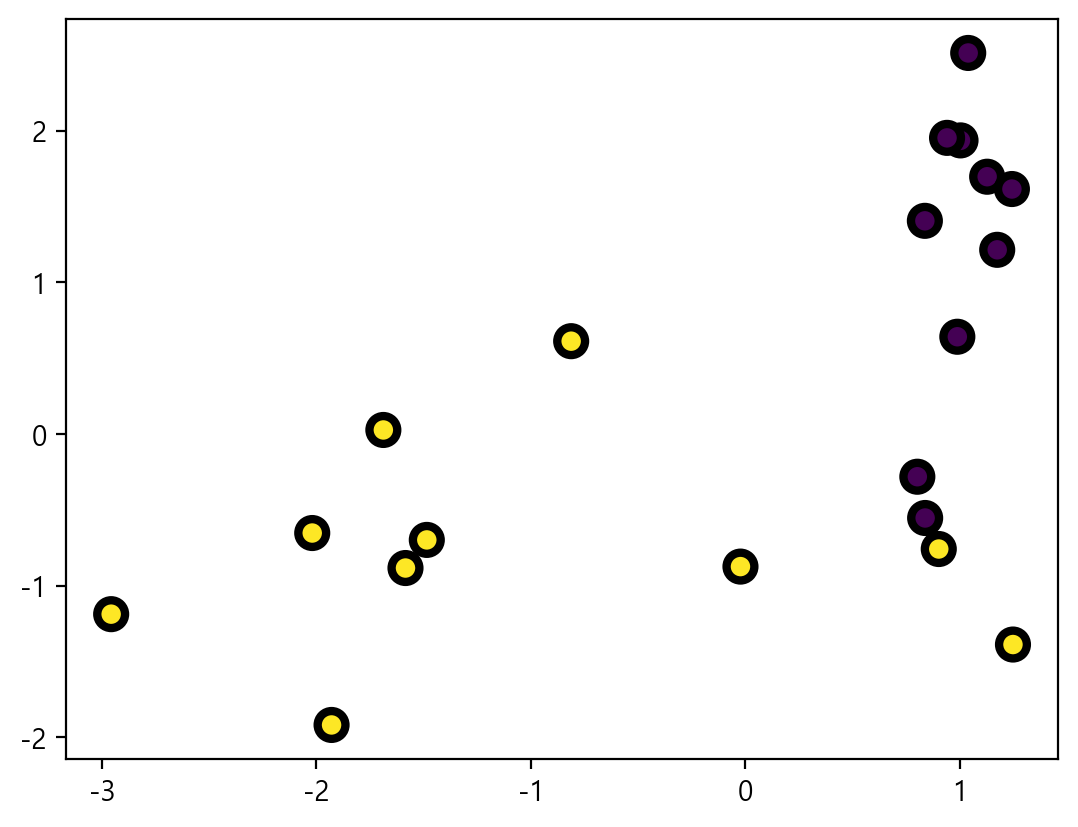

In [12]:
plt.scatter(x=X[:,0], y=X[:,1], c=y, s=100, edgecolors='k', lw=3)
plt.show()

In [16]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2, #군의 갯수
              init = "k-means++", #초기중심점을 서로 멀리 초기화. random(초기중심점랜덤)
               n_init=10, #각 다른 초기값을 10번 실행해보고 가장 좋은 모델 선택
               max_iter=300 #각 실행에서 300번 반복(중심 옮기기)
              )
model.fit(X)

KMeans(n_clusters=2, n_init=10)

In [24]:
c0, c1 = model.cluster_centers_ #모델이 정한 두 중심점
print(c0)
print(c1)

[1.01138251 0.83200493]
[-1.56258716 -0.69768199]


In [22]:
print('modelLabel :', model.labels_)
pred = model.predict(X)
print(' 예 측 값 :', pred)
print(' 실 제 값 :', y)

modelLabel : [0 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 1 0 0]
 예 측 값 : [0 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 1 0 0]
 실 제 값 : [0 0 1 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 0]


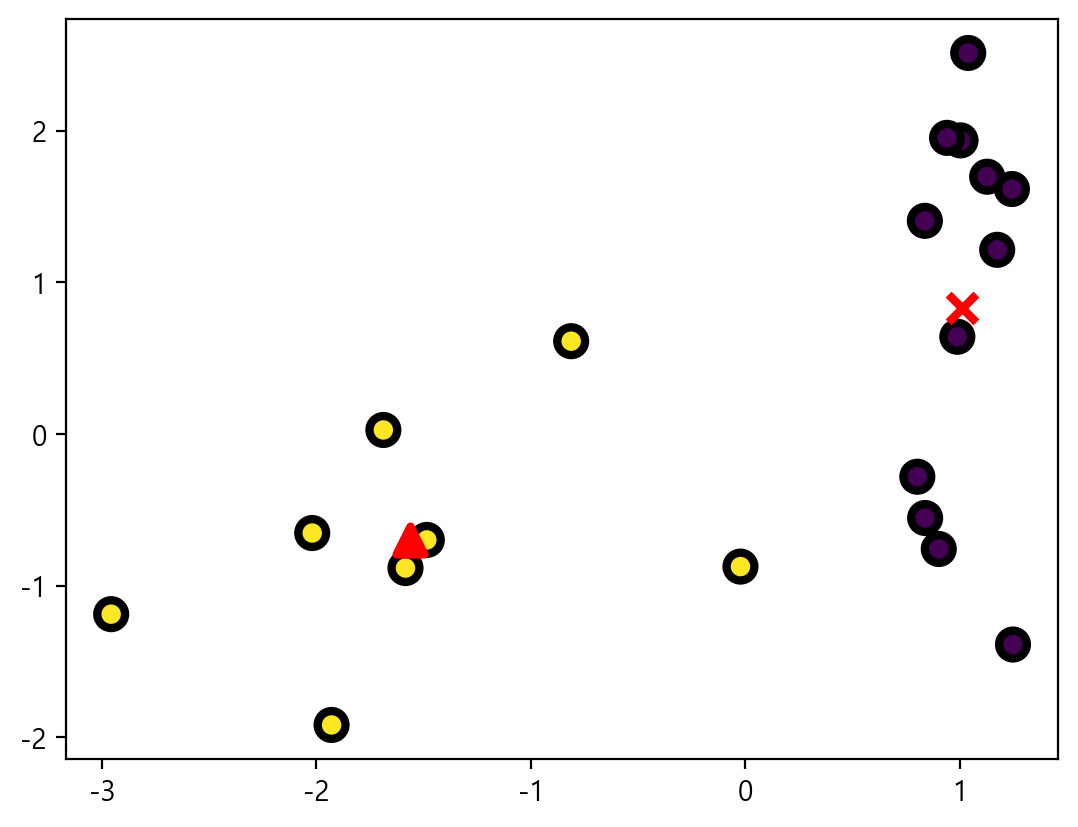

In [28]:
plt.scatter(x=X[:,0], y=X[:,1], c=pred, s=100, edgecolors='k', lw=3)
plt.scatter(x=c0[0], y=c0[1], c='r', s=100, marker='x', lw=3)
plt.scatter(x=c1[0], y=c1[1], c='r', s=100, marker='^', lw=3)
plt.show()

## cf. Normalizer 적용

In [31]:
import pandas as pd
from sklearn.preprocessing import Normalizer
scaler = Normalizer()
Xnor = scaler.fit_transform(X)
np.c_[X, Xnor]

array([[ 1.03859554,  2.51175389,  0.3821159 ,  0.92411441],
       [ 1.00271366,  1.93521549,  0.46005267,  0.88789162],
       [-1.6881048 ,  0.02599427, -0.99988146,  0.01539667],
       [ 0.90134424, -0.75896558,  0.76493676, -0.64410538],
       [ 0.83653082,  1.40488232,  0.51161542,  0.85921456],
       [-0.02317631, -0.87481215, -0.02648361, -0.99964925],
       [ 0.83780453, -0.554389  ,  0.83395074, -0.55183889],
       [-1.9295722 , -1.91894047, -0.7090575 , -0.70515067],
       [-0.8124957 ,  0.61140818, -0.79903769,  0.60128094],
       [ 1.12694685,  1.69570061,  0.55350265,  0.83284742],
       [ 0.80138648, -0.28232585,  0.94318094, -0.33227958],
       [ 0.9399586 ,  1.9518949 ,  0.43387458,  0.90097328],
       [ 1.24232232,  1.6146173 ,  0.60980605,  0.79255068],
       [-1.48554751, -0.69890985, -0.90485891, -0.42571159],
       [ 1.24732102, -1.38872822,  0.66821427, -0.74396888],
       [-2.95714561, -1.18843377, -0.92787221, -0.37289833],
       [-1.5849172 , -0.

In [32]:
model = KMeans(n_clusters=2, #군의 갯수
              init = "k-means++", #초기중심점을 서로 멀리 초기화. random(초기중심점랜덤)
               n_init=10, #각 다른 초기값을 10번 실행해보고 가장 좋은 모델 선택
               max_iter=300 #각 실행에서 300번 반복(중심 옮기기)
              )
model.fit(Xnor)

KMeans(n_clusters=2, n_init=10)

In [33]:
model.labels_# 모델이 그룹핑한 결과

array([1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1])

In [34]:
d0, d1 = model.cluster_centers_ #모델이 정한 중심점
print(d0, d1)

[-0.77398837 -0.33522479] [0.64128684 0.34902823]


In [39]:
Xnor[model.labels_==0]

array([[-0.99988146,  0.01539667],
       [-0.02648361, -0.99964925],
       [-0.7090575 , -0.70515067],
       [-0.79903769,  0.60128094],
       [-0.90485891, -0.42571159],
       [-0.92787221, -0.37289833],
       [-0.87327958, -0.48721942],
       [-0.95143599, -0.30784666]])

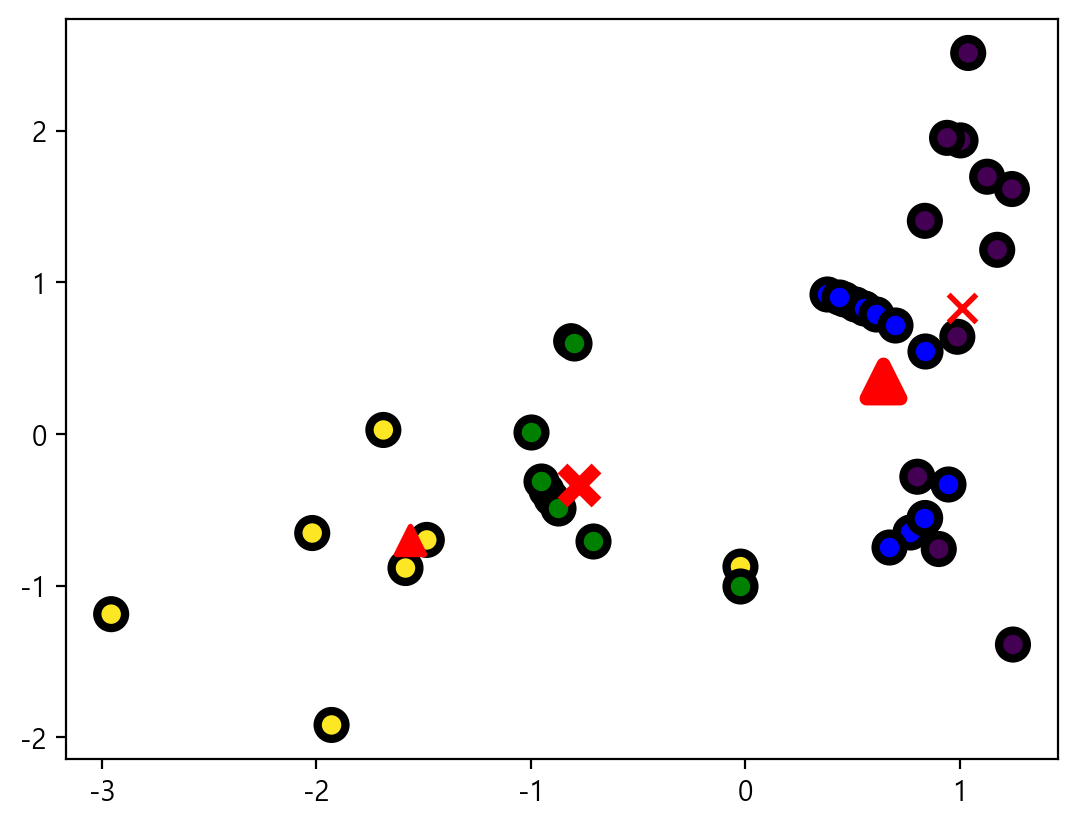

In [45]:
plt.scatter(x=X[:,0], y=X[:,1], c=pred, s=100, edgecolors='k', lw=3)
plt.scatter(x=c0[0], y=c0[1], c='r', s=100, marker='x', lw=2)
plt.scatter(x=c1[0], y=c1[1], c='r', s=100, marker='^', lw=2)
plt.scatter(x=Xnor[model.labels_==0,0], 
            y=Xnor[model.labels_==0,1], 
            c='g', s=100, edgecolors='k', lw=3)
plt.scatter(x=Xnor[model.labels_==1,0], 
            y=Xnor[model.labels_==1,1], 
            c='b', s=100, edgecolors='k', lw=3)
plt.scatter(x=d0[0], y=d0[1], c='r', s=150, marker='x', lw=5)
plt.scatter(x=d1[0], y=d1[1], c='r', s=150, marker='^', lw=5)
plt.show()

### K-Means 클러스터링의 한계점(pt13)
- 군의 특성이 다를 경우
    - 크기
    - 군의 밀도
    - 비구형
- 이상치를 포함할 경우 : 이상치를 조정하거나 삭제한 후 클러스터링

### - 군의 크기가 다를 경우

In [50]:
import numpy as np
np.random.seed(0)
# 평균:-10, 표준편차:2인 10행 2열 데이터 : group0
group0 = np.random.normal(loc=-10, scale=2, size=(10,2))
y = np.full(group0.shape[0], 0)
group0 = np.c_[group0, y]
group0

array([[ -6.47189531,  -9.19968558,   0.        ],
       [ -8.04252403,  -5.5182136 ,   0.        ],
       [ -6.26488402, -11.95455576,   0.        ],
       [ -8.09982316, -10.30271442,   0.        ],
       [-10.2064377 ,  -9.178803  ,   0.        ],
       [ -9.71191286,  -7.09145299,   0.        ],
       [ -8.47792455,  -9.75664997,   0.        ],
       [ -9.11227353,  -9.33265135,   0.        ],
       [ -7.01184185, -10.41031653,   0.        ],
       [ -9.3738646 , -11.70819148,   0.        ]])

In [52]:
# 평균:10, 표준편차:2인 10행 2열 데이터 : group1
group1 = np.random.normal(loc=10, scale=2, size=(10,2))
y = np.full(group1.shape[0],1)
group1 = np.c_[group1, y]
group1

array([[ 7.90289407,  7.15996413,  1.        ],
       [ 6.58745962, 13.90155079,  1.        ],
       [ 8.98069564,  9.1238514 ,  1.        ],
       [ 7.49440928, 11.55498071,  1.        ],
       [ 6.7722043 ,  9.57451944,  1.        ],
       [ 8.20906688, 10.773805  ,  1.        ],
       [ 8.97838972,  7.63873563,  1.        ],
       [ 9.94363554, 10.85666374,  1.        ],
       [10.13303444, 10.6049438 ,  1.        ],
       [ 8.73135581,  9.27451767,  1.        ]])

In [54]:
# 평균:0, 표준편차:5인 100행 2열 데이터 : group2
group2 = np.random.normal(loc=0, scale=5, size=(100,2))
y = np.full(group2.shape[0], 2)
group2 = np.c_[group2, y]
group2

array([[ -5.8257492 ,   4.50413243,   2.        ],
       [  2.3283122 ,  -7.68121843,   2.        ],
       [  7.44126097,   9.47944588,   2.        ],
       [  5.89389786,  -0.89962418,   2.        ],
       [ -5.35376311,   5.27225863,   2.        ],
       [ -2.01588473,   6.11222535,   2.        ],
       [  1.04137489,   4.88319518,   2.        ],
       [  1.78183199,   3.53286584,   2.        ],
       [  0.0525001 ,   8.92935247,   2.        ],
       [  0.63456046,   2.00994682,   2.        ],
       [  9.41575349,  -6.73879531,   2.        ],
       [ -6.35242499,   4.84698354,   2.        ],
       [ -5.86561703,   9.71810593,   2.        ],
       [ -2.0680949 ,  -3.73727406,   2.        ],
       [  9.61471013,   7.40257396,   2.        ],
       [  9.3377948 ,   4.53022329,   2.        ],
       [ -4.30612843,   9.55032477,   2.        ],
       [ -1.34001685,   4.01228198,   2.        ],
       [  4.73625984,  -0.77505047,   2.        ],
       [  3.07039685,   4.61103

In [55]:
data = np.r_[group0, group1, group2]
data[::10], data.shape

(array([[-6.47189531, -9.19968558,  0.        ],
        [ 7.90289407,  7.15996413,  1.        ],
        [-5.8257492 ,  4.50413243,  2.        ],
        [ 9.41575349, -6.73879531,  2.        ],
        [ 1.88212766, -5.49700395,  2.        ],
        [-7.45628796,  2.19695851,  2.        ],
        [-2.49016225,  9.64766027,  2.        ],
        [-1.76996956, -6.87475647,  2.        ],
        [-1.84590919, -1.19689589,  2.        ],
        [-4.779725  , -1.72990888,  2.        ],
        [-3.18718513, -1.98635907,  2.        ],
        [-5.94429629, -2.53408177,  2.        ]]),
 (120, 3))

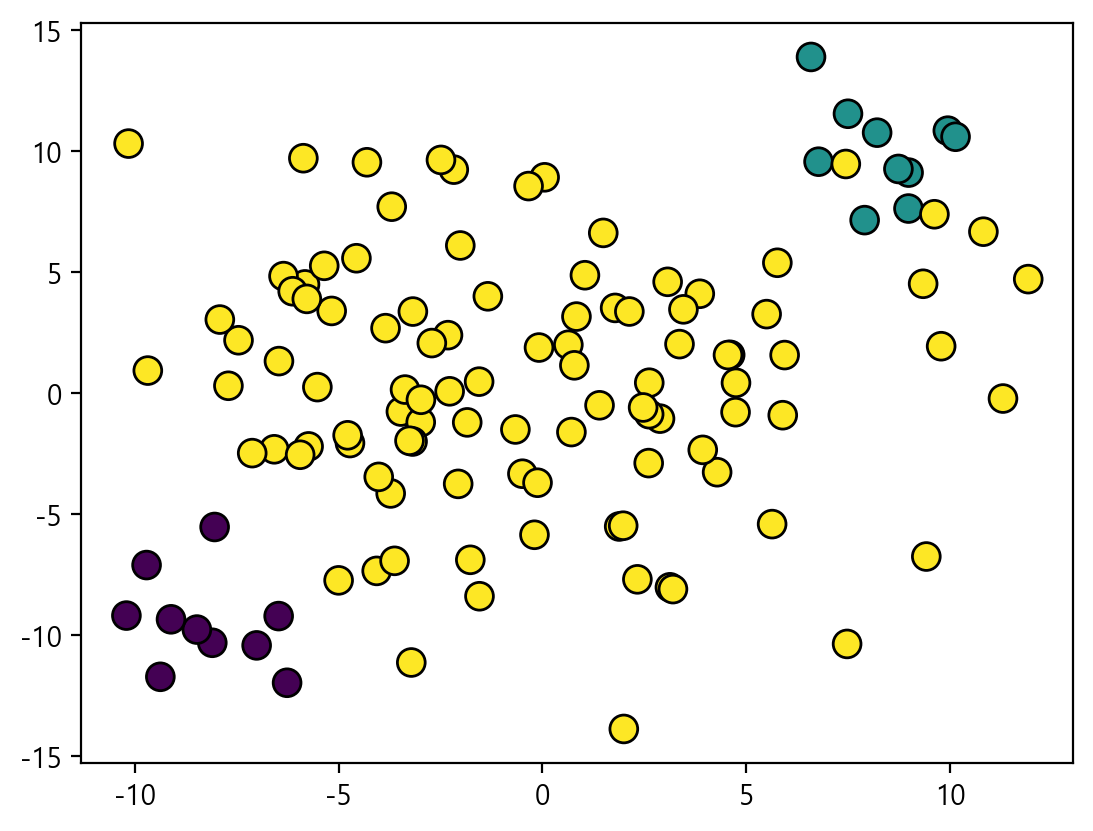

In [58]:
plt.scatter(x=data[:,0], y=data[:,1], c=data[:,2], s=100, edgecolors='k')
plt.show()

In [59]:
model = KMeans(n_clusters=3,
              init="k-means++",
              n_init="auto",
              max_iter=300)
model.fit(data[:, :2])

KMeans(n_clusters=3, n_init='auto')

In [60]:
c = model.cluster_centers_ #중심점
c

array([[-2.68368121, -6.37575726],
       [ 8.55675129,  7.26395591],
       [-1.42283134,  2.82173963]])

In [63]:
pred = model.labels_
pred = model.predict(data[:,:2]) #모델이 클러스터링한 결과(위와 같음)

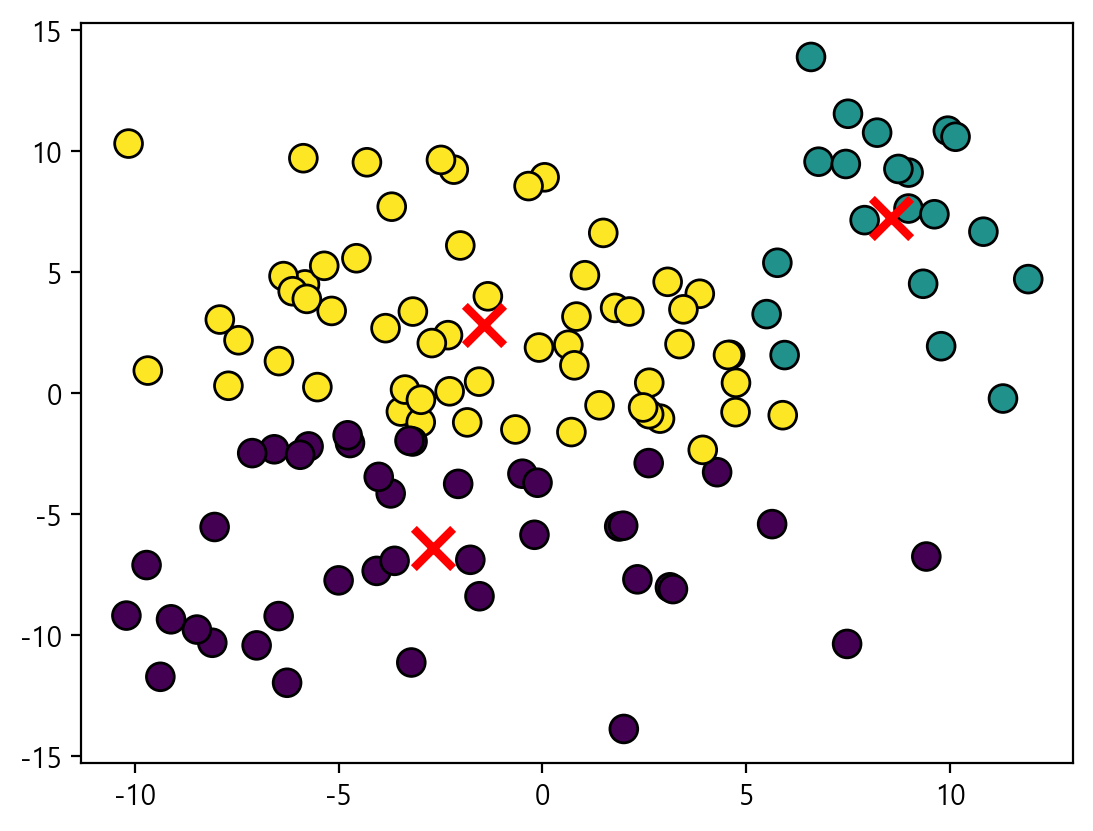

In [65]:
plt.scatter(x=data[:,0], y=data[:,1], c=pred, s=100, edgecolors='k')
plt.scatter(x=c[:,0], y=c[:,1], c='r', marker='x', s=200, lw=3)
plt.show()

In [69]:
model = KMeans(n_clusters=6, init='k-means++', n_init=10)
model.fit(data[:,:2])

KMeans(n_clusters=6, n_init=10)

In [72]:
c = model.cluster_centers_ #중심점
pred = model.labels_ #모델이 클러스터(군집화)한 결과
pred

array([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 0, 1,
       5, 2, 0, 0, 2, 2, 0, 2, 1, 0, 0, 3, 5, 5, 0, 0, 2, 2, 1, 2, 3, 0,
       2, 3, 3, 0, 2, 1, 3, 2, 5, 0, 3, 0, 3, 1, 1, 3, 0, 2, 0, 4, 2, 2,
       1, 0, 3, 3, 1, 4, 1, 3, 0, 3, 1, 2, 2, 5, 3, 2, 1, 1, 2, 2, 2, 3,
       2, 2, 3, 3, 3, 2, 3, 3, 3, 0, 1, 2, 3, 3, 1, 2, 4, 1, 2, 2, 4, 3,
       3, 3, 3, 2, 3, 1, 2, 3, 2, 0])

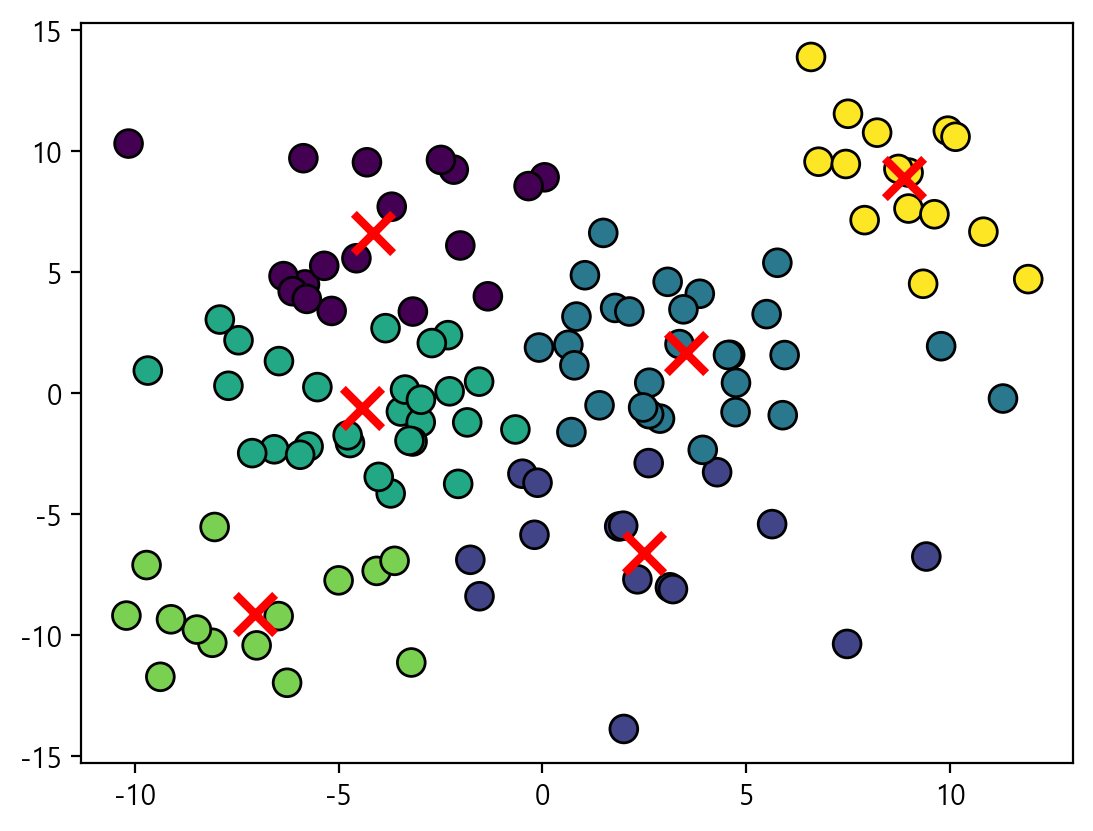

In [73]:
plt.scatter(x=data[:,0], y=data[:,1], c=pred, s=100, edgecolors='k')
plt.scatter(x=c[:,0], y=c[:,1], c='r', marker='x', s=200, lw=3)
plt.show()

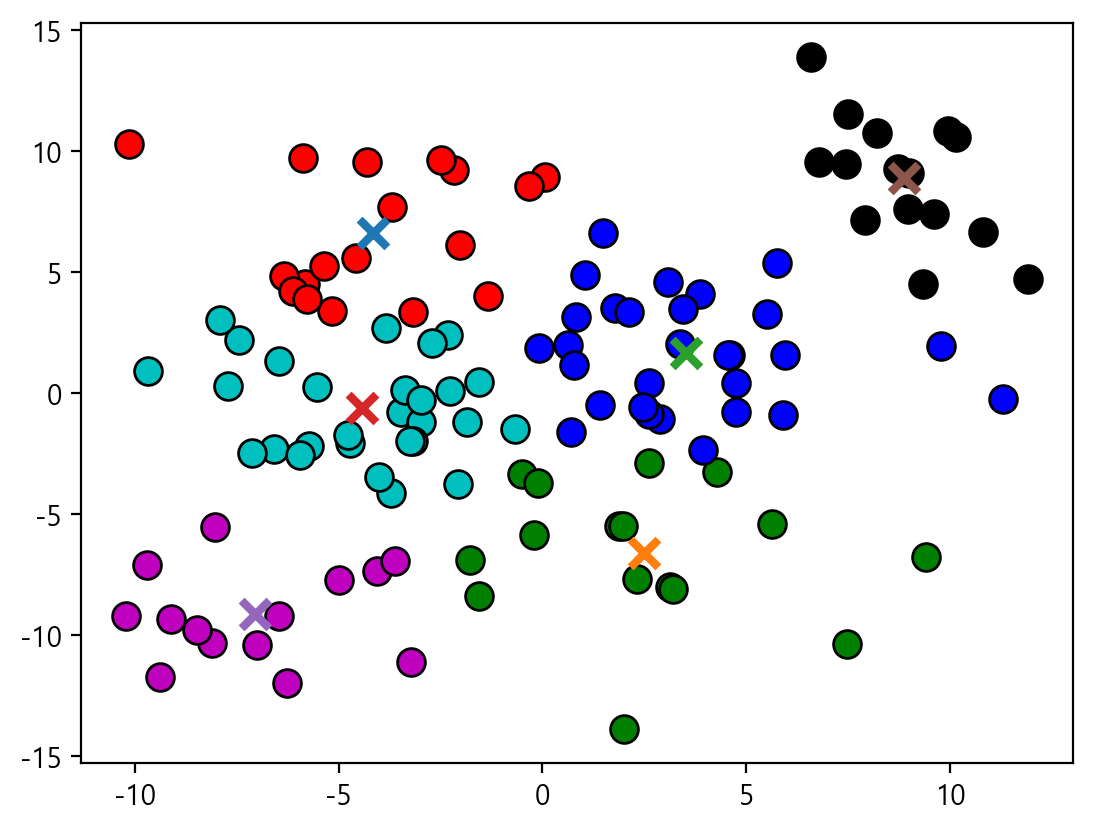

In [80]:
colors = ['r', 'g', 'b', 'c', 'm', 'k'] #012345
for i in range(len(c)):
    plt.scatter(x=data[pred==i,0], y=data[pred==i,1], c=colors[i], s=100, edgecolors='k')
    plt.scatter(x=c[i,0], y=c[i,1], marker='x', s=100, lw=3)

# 3절. Hierachical 클러스터링(계층적 군집)

- 계층적분석(linkage) -> dendrogram -> fcluster를 이용해서 클러스터를 생성(군집화)
    - 군끼리 묶으면서 최종적으로 하나의 군집이 될 때까지 묶는 클러스터링
    - 군집의 수를 미리 정해주지 않음
    - 군집간의 거리 기반으로 클러스터링

In [81]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.sample()

,sepal_length,sepal_width,petal_length,petal_width,species
56,6.3,3.3,4.7,1.6,versicolor


In [83]:
# 계층적 군집 적용을 위해 라벨인코딩
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
iris.species = le.fit_transform(iris.species)

In [84]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [85]:
from scipy.cluster.hierarchy import linkage
# method : 거리계산을 어떻게 할 지
# method="complete" : 두 클러스터에서 가장 먼 거리를 이용
# method="single" : 두 클러스터에서 가장 가까운 거리를 이용
# method="average" : 두 클러스터내의 각 점에서 다른 클러스터의 모든 점의 평균거리를 이용
cluster_model = linkage(iris, method="complete")

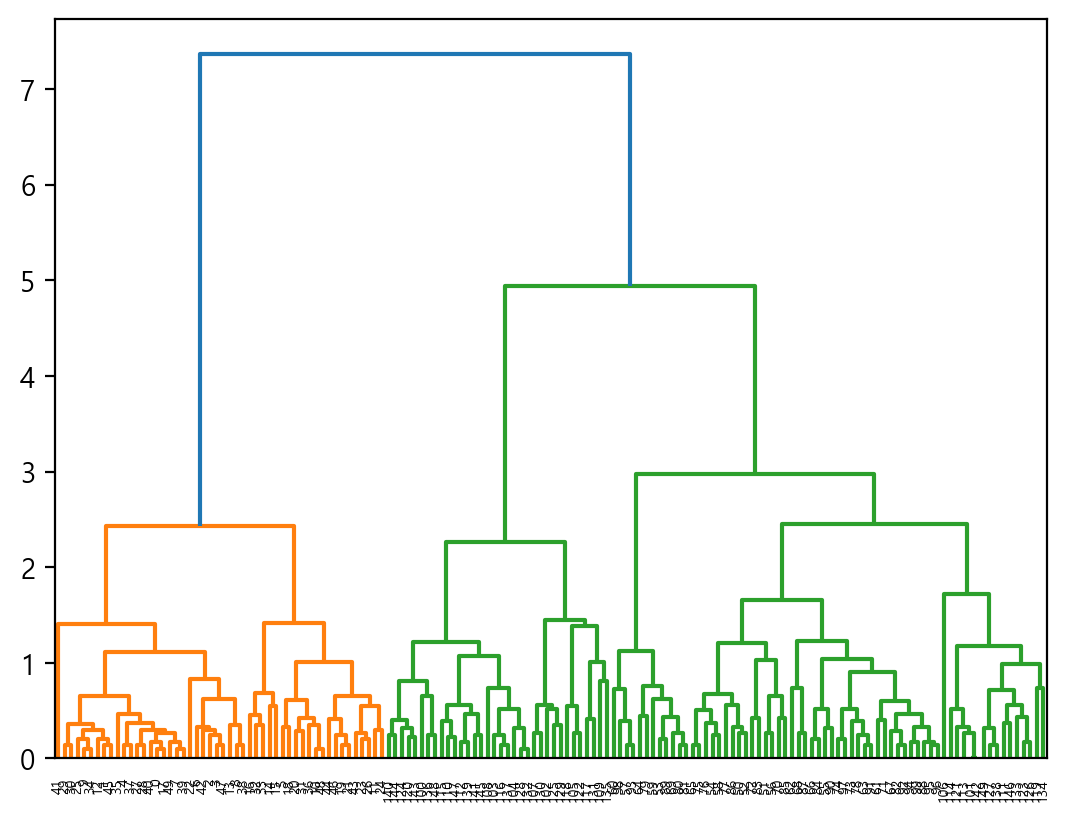

In [86]:
from scipy.cluster.hierarchy import dendrogram
dendrogram(cluster_model, labels=iris.index)
plt.savefig('data/ch02_iris.png', dpi=300, bbox_inches='tight')
plt.show()

In [87]:
from scipy.cluster.hierarchy import fcluster #군집화
fcluster(cluster_model, 
         t=4, #dendrogram의 y축 값
         criterion="distance" #군집화 기준
        )
# criterion="distance" 일 때, t값은 dendrogram의 y축 값

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [89]:
fcluster(cluster_model,
        t=3,
        criterion="maxclust")
# criterion="maxclust" 일 때, t값은 클러스터의 갯수(군집화된 그룹 갯수)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [90]:
fcluster(cluster_model, 5, criterion="distance")

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

# 4절. DBSCAN 클러스터링
- 연결 기반(밀도기반) 군집화알고리즘
- 단점 : 클러스터의 밀도가 일정하지 않으면 성능이 낮아짐

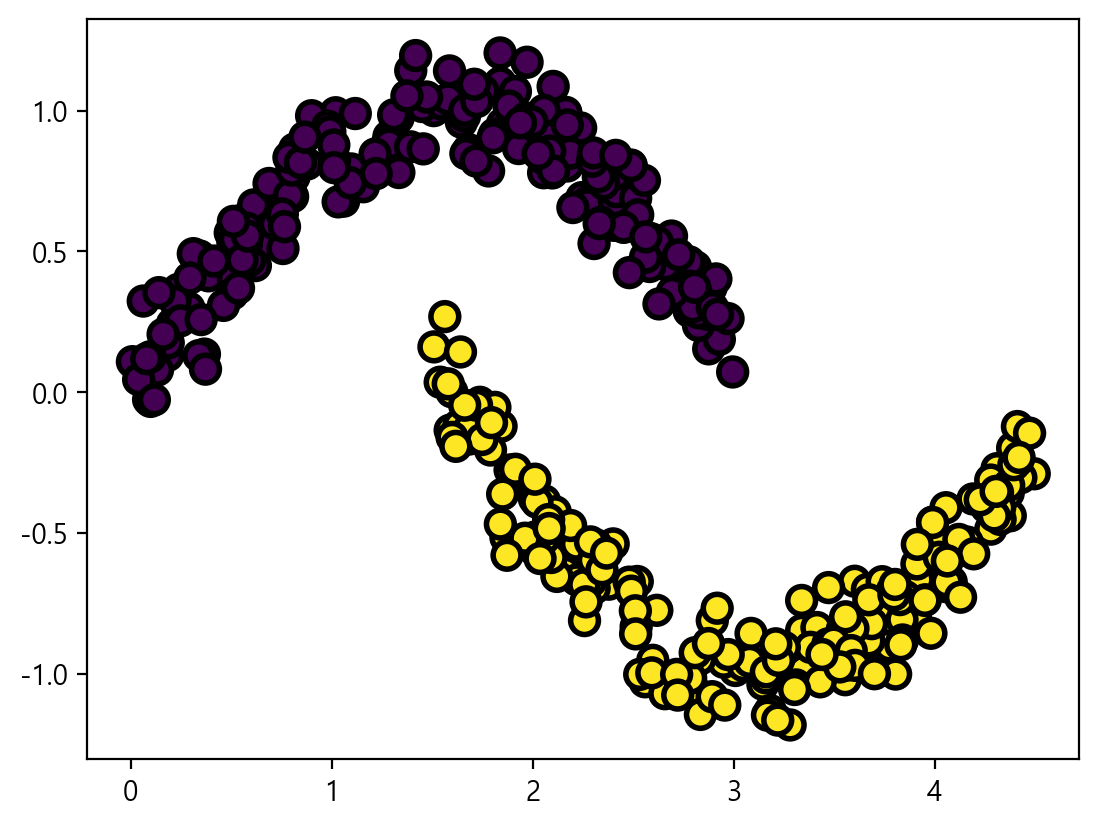

In [99]:
X1 = np.random.rand(200)*3 # rand() : 0~2사이의 실수 난수 발생
noise = np.random.normal(0, 0.1, 200)
Y1 = np.sin(X1) + noise
group1 = np.c_[X1, Y1, np.full(200,0)]

X2 = X1+1.5
Y2 = np.cos(X2) + noise
group2 = np.c_[X2, Y2, np.full(200,1)]
data = np.r_[group1, group2]

plt.scatter(data[:,0], data[:,1], c=data[:,2], s=100, edgecolors='k', lw=2)

In [100]:
from sklearn.cluster import DBSCAN
# 반경 0.3이내에 최소 10개는 있어야 군집 시작
db = DBSCAN(eps=0.3, min_samples=10)
db.fit(data[:,:2])

DBSCAN(eps=0.3, min_samples=10)

In [108]:
db.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [112]:
labels = db.labels_ #모델이 군집화한 결과 (-1이상치 인식)
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0) #클러스터 수
n_noise_ = list(labels).count(-1)
print(f'이상치를 제외한 클러스터수 :{n_clusters_}, 이상치갯수:{n_noise_}')

이상치를 제외한 클러스터수 :2, 이상치갯수:0


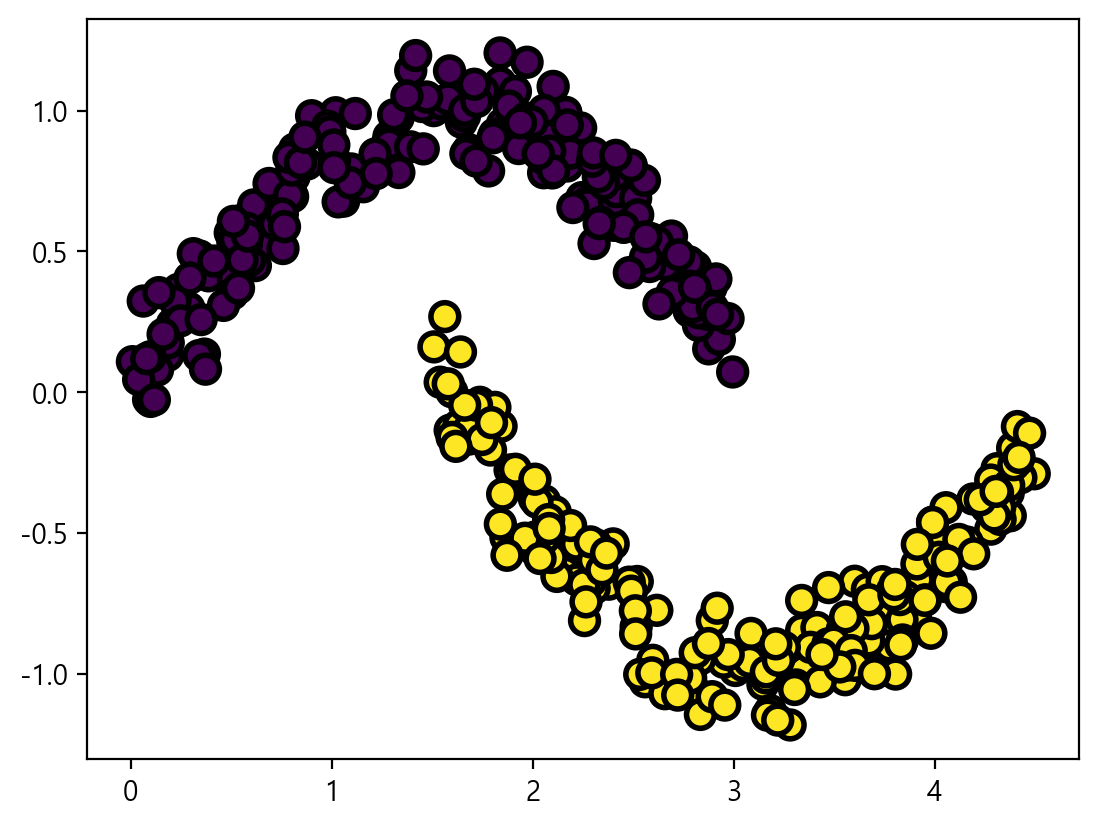

In [114]:
plt.scatter(data[:,0], data[:,1], c=labels, s=100, edgecolors='k', lw=2)

# 5절. 모형 성능평가
- score메소드를 통해 예측 모형 평가(분류, 회귀. 군집에서는 안 씀)
- metrics 모듈의 메소드를 통해 군집 모형 평가

## 5.1 metrics 함수이용
    - 클러스터의 소속과 갯수를 모두 알고 있을 경우 평가

In [116]:
iris.sample()

,sepal_length,sepal_width,petal_length,petal_width,species
76,6.8,2.8,4.8,1.4,1


In [117]:
iris_X = iris.iloc[:,:-1]
iris_y = iris.iloc[:,-1]
iris_X.shape, iris_y.shape

((150, 4), (150,))

In [119]:
iris_cluster_model3 = KMeans(n_clusters=3, n_init=10, random_state=1)
iris_cluster_model3.fit(iris_X)

KMeans(n_clusters=3, n_init=10, random_state=1)

In [122]:
pred = iris_cluster_model3.labels_
pred = iris_cluster_model3.predict(iris_X)
pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0])

In [123]:
#pred조정을 위해 : np.choose(배열시퀀스, 배열)
np.choose([3,2,2,3],[0,10,20,30])

array([30, 20, 20, 30])

In [124]:
np.choose([1,1,1,1,0,0,0,2,2,2], [1,0,2])

array([0, 0, 0, 0, 1, 1, 1, 2, 2, 2])

In [129]:
pred3 = np.choose(pred, [1,0,2])
pred3 #조정된 예측값

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1])

In [131]:
# 3개 cluster로 군집화한 자료
print('실제값 :', iris_y[::50])
print('예측값 :', pred3[::50])

실제값 : 0      0
50     1
100    2
Name: species, dtype: int32
예측값 : [0 1 2]


In [133]:
iris_model2 = KMeans(n_clusters=2, n_init=10, random_state=1)
iris_model2.fit(iris_X)

KMeans(n_clusters=2, n_init=10, random_state=1)

In [136]:
pred2 = iris_model2.labels_

In [137]:
# 2개 cluster로 군집화한 자료
iris_y2 = np.array([0]*50 + [1]*100)
print('실제값 : ', iris_y2)
print('예측값 : ', pred2)

실제값 :  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]
예측값 :  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]


In [139]:
# 클러스터가 3개인 경우 평가
from sklearn.metrics import adjusted_rand_score
adjusted_rand_score(labels_true=iris_y, # 실제값
                   labels_pred=pred3) #클러스터링 예측

0.7302382722834697

In [140]:
# 클러스터가 2개인 경우 평가
adjusted_rand_score(labels_true=iris_y2,
                   labels_pred=pred2)

0.920405050901892

In [142]:
from sklearn.metrics import mutual_info_score #상호 의존도를 나타내는 지표
# 클러스터가 3개인 경우 평가
mutual_info_score(iris_y, pred3)

0.8255910976103356

In [143]:
# 클러스터가 2개인 경우 평가
mutual_info_score(iris_y2, pred2)

0.5596576064224734

In [144]:
from sklearn.metrics import v_measure_score
v_measure_score(iris_y, pred3)

0.7581756800057784

In [145]:
v_measure_score(iris_y2, pred2) # 2개 그룹으로 군집화하는것이 좋은 성능이다

0.870385156563164

## 5.2 실루엣 계수
- 클러스터 개수, 소속을 모두 모르고 있을 경우 평가

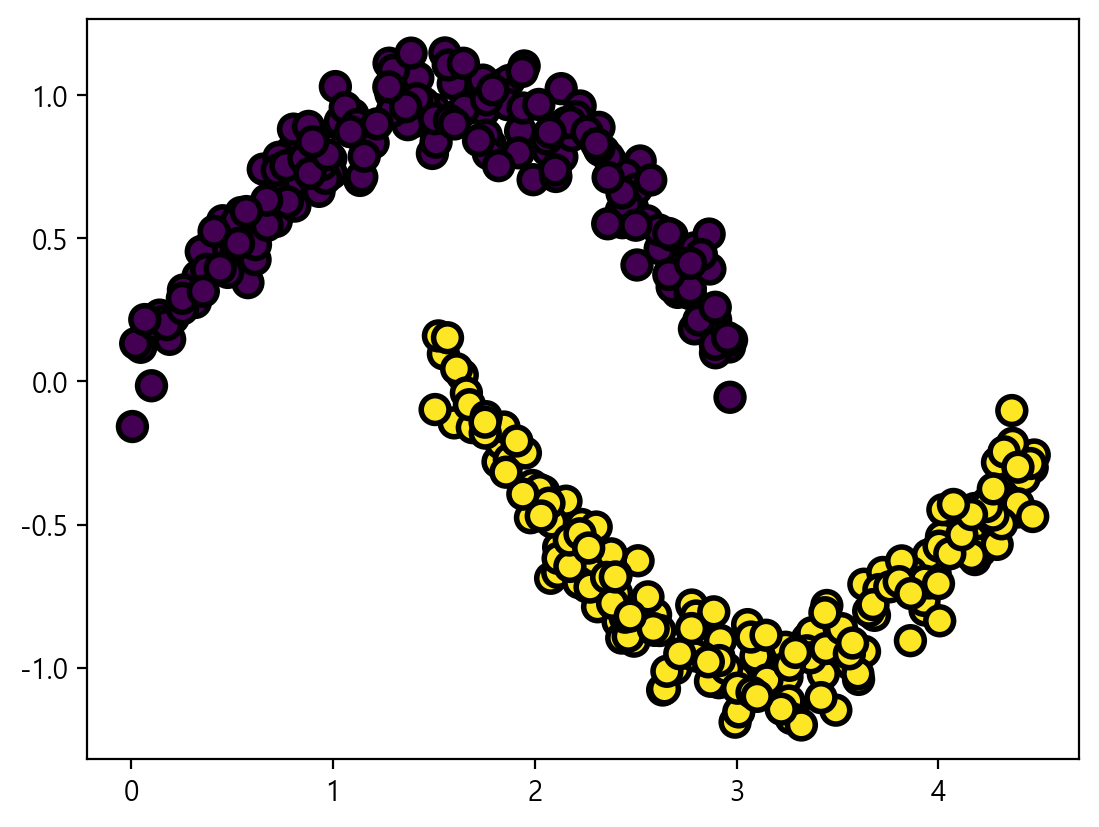

In [146]:
X1 = np.random.rand(200)*3 # rand() : 0~2사이의 실수 난수 발생
noise = np.random.normal(0, 0.1, 200)
Y1 = np.sin(X1) + noise
group1 = np.c_[X1, Y1, np.full(200,0)]

X2 = X1+1.5
Y2 = np.cos(X2) + noise
group2 = np.c_[X2, Y2, np.full(200,1)]
data = np.r_[group1, group2]

plt.scatter(data[:,0], data[:,1], c=data[:,2], s=100, edgecolors='k', lw=2)

In [147]:
from sklearn.metrics import silhouette_score
range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9, 10]
for n_clusters in range_n_clusters:
    model = KMeans(n_clusters=n_clusters,
                  n_init=10,
                  random_state=2)
    model.fit(data[:,:-1])
    score = silhouette_score(X=data[:,:-1],
                            labels=model.labels_)
    print('클러스터수 : {}, 실루엣 계수 : {}'.format(n_clusters, score))
# 실루엣 계수가 가장 높은 7개로 클러스터링 할 예정

클러스터수 : 2, 실루엣 계수 : 0.5299280136729965
클러스터수 : 3, 실루엣 계수 : 0.47533854564634054
클러스터수 : 4, 실루엣 계수 : 0.5161733949728116
클러스터수 : 5, 실루엣 계수 : 0.5158209285184562
클러스터수 : 6, 실루엣 계수 : 0.5343219529514172
클러스터수 : 7, 실루엣 계수 : 0.5379307853277927
클러스터수 : 8, 실루엣 계수 : 0.5317725531191053
클러스터수 : 9, 실루엣 계수 : 0.5320533966771694
클러스터수 : 10, 실루엣 계수 : 0.522570265778031


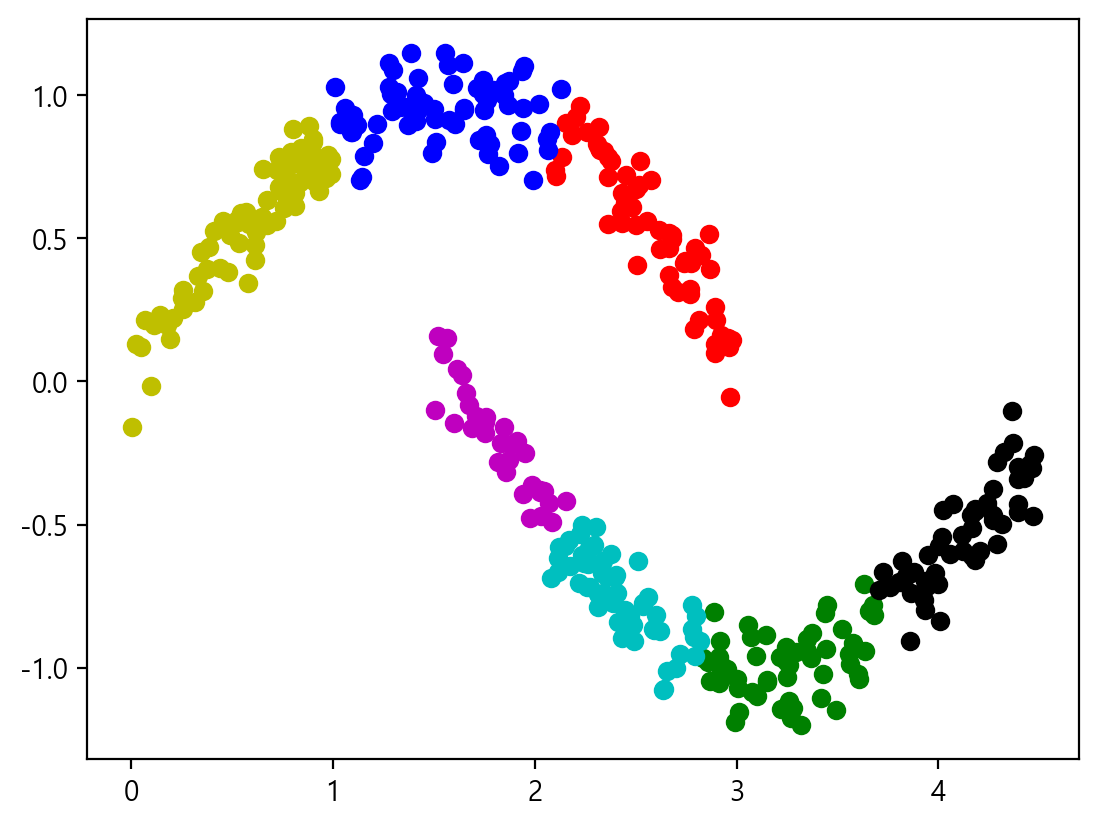

In [151]:
model = KMeans(n_clusters=7, n_init=10, init="k-means++")
model.fit(data[:,:-1])
centers = model.cluster_centers_
colors = ['r', 'g', 'b', 'c', 'm', 'k', 'y']
for i in range(len(colors)):
    plt.scatter(data[model.labels_==i,0], data[model.labels_==i,1], c=colors[i])